In [41]:
import pandas as pd
import numpy as np

In [42]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'
df = pd.read_csv(data)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [43]:
# Clean the data to avoid redundancy
# Replace spaces with underscores, make everything lowercase

df.columns = df.columns.str.lower().str.replace(' ', '_')
string_columns = list(df.dtypes[df.dtypes == 'str'].index)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')
    
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

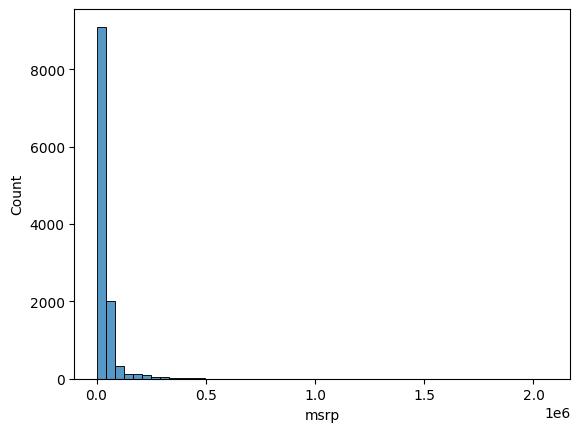

In [45]:
sns.histplot(df.msrp, bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

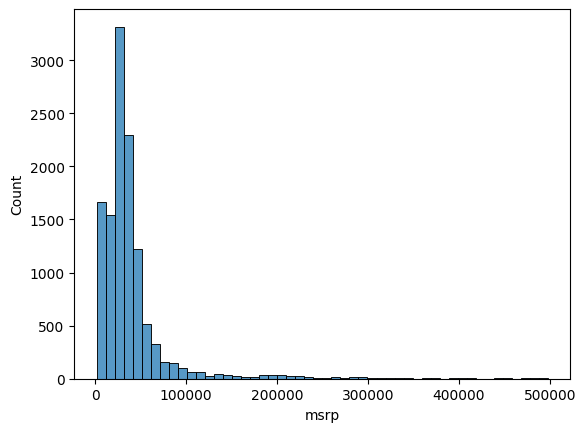

In [46]:
sns.histplot(df.msrp[df.msrp < 500000], bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

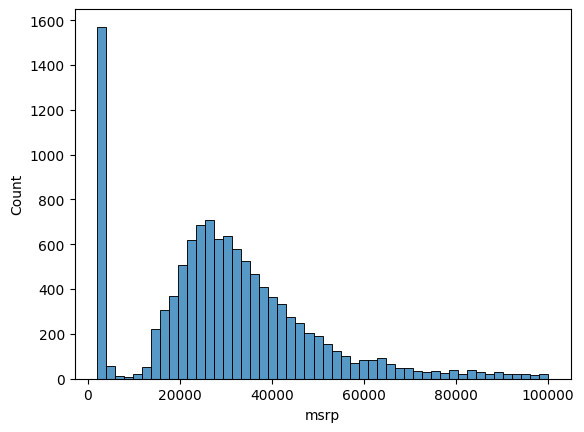

In [47]:
sns.histplot(df.msrp[df.msrp < 100000], bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

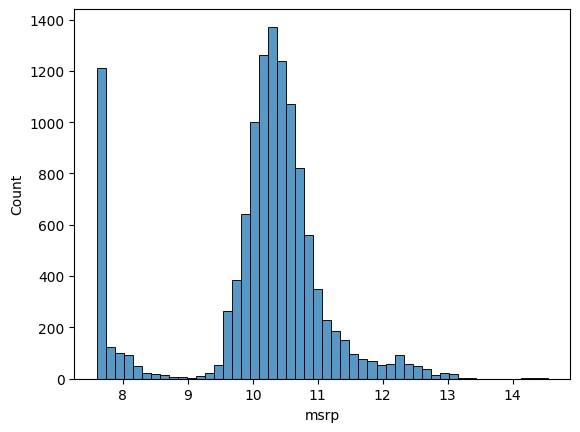

In [48]:
# long-tailed distributions confuse ml models and are not suitable 
# Hence we take log of the prices (+1, to avoid log 0), which gives a somewhat normal distribution 

logarithmic_prices = np.log1p(df.msrp)
sns.histplot(logarithmic_prices, bins = 50)

In [49]:
# Check for missing values
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [50]:
# Setup the training, validation and test data
n = len(df)
n_val = int(0.2 * len(df))
n_test = int(0.2 * len(df))
n_train = n - n_val - n_test

# Shuffle the rows to remove bias due to sequence
ids = np.arange(n)
np.random.seed(3)
np.random.shuffle(ids)
df_train = df.iloc[ids[:n_train]]
df_val = df.iloc[ids[n_train : n_train+n_val]]
df_test = df.iloc[ids[n_train+n_val : n-1]]

In [51]:
# Calculate the y values
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

# Delete the msrp variable to avoid using it in the future
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

<Axes: ylabel='Count'>

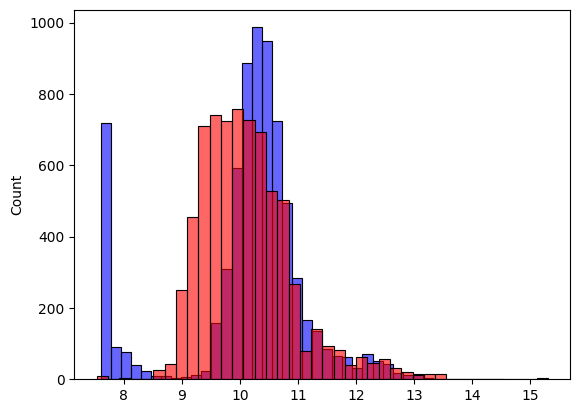

In [52]:
# Linear Regression:
# g(Xi) = yi
# Xi is a vector containing features of the ith car, and yi is the logarithmic price of the car 
# We try to fit a function (vector) g so that g.Xi is approximately yi for all Xs and ys
# g(Xi) = W0 + W1*Xi1 + W2*Xi2 + W3*Xi3
# Features of th ith car are represented by the ith row in the matriX X, so we need to find the solution to the equation X.w = y
# X has a lot of rows (large number of cars) and few columns - it is rectangular, its inverse does not exist, the equation is not solvable
# We multiply by XT, then [XT.X.w = XT.y], XT.X is a square matrix, hence multiply by the inverse
# Now w = (XT.X)^(-1).XT.y is the closest possible solution


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
def prepare_X(df):
    X = df[base].fillna(0).values
    return X
    
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)

sns.histplot(y_train, color='blue', alpha=0.6, bins=40)
sns.histplot(y_pred, color='red', alpha=0.6, bins=40)

In [53]:
# RMSE = sqrt([g(Xi)-yi)^2]/m)

def rmse(y_a, y_p):
    error = y_a - y_p
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

rmse(y_train, y_pred)

np.float64(0.7530702635167188)

In [54]:
# RMSE for validation data set

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7460612947996883)

In [55]:
# Feature Engineering - Age is a very important factor that helps decide the price of a car, feature engineering helps with this

def prepare_X(df):
    df = df.copy()
    features = base.copy()
    df['age'] = 2017 - df.year
    features = features + ['age']
    X = df[features].fillna(0).values
    return X

In [58]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)
rmse(y_train, y_pred)
print('train:', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)
print('val:', rmse(y_val, y_pred))


train: 0.5190023824313631
val: 0.512385164444267


<Axes: ylabel='Count'>

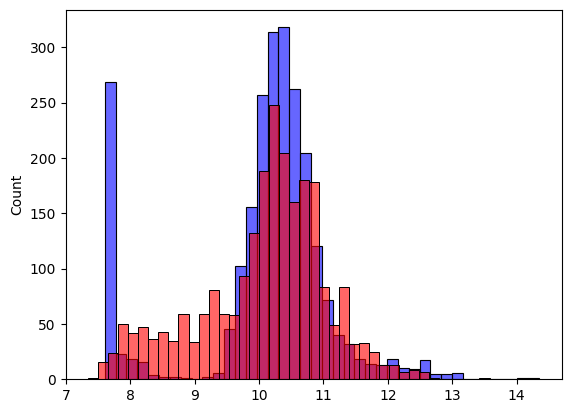

In [59]:
sns.histplot(y_val, color='blue', alpha=0.6, bins=40)
sns.histplot(y_pred, color='red', alpha=0.6, bins=40)